# Улучшение модели классификации болезней кукурузы

**Базовая модель:** ResNet18 (лучшая модель среди базовых архитектур)

**Структура:**
- Block 1: Переобучение (1.1 Strong Aug / 1.2 Label Smoothing / 1.3 Weight Decay)
- Block 2: Gray_Leaf_Spot (2.1 Weighted Loss / 2.2 Oversampling)
- Block 3: Fine-tune strategy (3.1 Two-phase / 3.2 Discriminative LR)
- Block 4: Final comparison

In [ ]:
import os, json, time, copy
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights


import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from PIL import Image
from src.models.training import (
    CornDiseaseDataset,
    make_class_weights,
    make_weighted_sampler,
    train_one_epoch,
    evaluate,
    make_resnet,
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, classification_report

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

IMG_SIZE      = 224
BATCH_SIZE    = 64
NUM_EPOCHS    = 40
MIN_EPOCHS    = 10   # не останавливаемся раньше этой эпохи
PATIENCE      = 7    # сколько эпох ждать улучшения перед остановкой
ARTIFACTS_DIR = '../artifacts'
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

os.makedirs(ARTIFACTS_DIR, exist_ok=True)

os.makedirs(f'{ARTIFACTS_DIR}/models',  exist_ok=True)
os.makedirs(f'{ARTIFACTS_DIR}/figures', exist_ok=True)

SPLITS_DIR = "../splits"
df_train = pd.read_csv(f"{SPLITS_DIR}/train.csv")
df_val   = pd.read_csv(f"{SPLITS_DIR}/val.csv")
df_test  = pd.read_csv(f"{SPLITS_DIR}/test.csv")

# ── splits ──────────────────────────────────────────────────────────────────
# Читаем готовые сплиты из project/splits
SPLITS_DIR = '../splits'
df_train = pd.read_csv(f'{SPLITS_DIR}/train.csv')
df_val   = pd.read_csv(f'{SPLITS_DIR}/val.csv')
df_test  = pd.read_csv(f'{SPLITS_DIR}/test.csv')

CLASSES      = sorted(df_train['label'].unique().tolist())
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASSES)}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
NUM_CLASSES  = len(CLASSES)
print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')
print(f'Classes: {CLASSES}')

# ── transforms ──────────────────────────────────────────────────────────────
BASE_TRAIN_TF = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

STRONG_TRAIN_TF = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=20),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.RandomGrayscale(p=0.05),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.3, scale=(0.02, 0.15))
])

VAL_TEST_TF = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_dataset  = CornDiseaseDataset(df_val,  CLASS_TO_IDX, VAL_TEST_TF)
test_dataset = CornDiseaseDataset(df_test, CLASS_TO_IDX, VAL_TEST_TF)
loader_kw = dict(num_workers=2, pin_memory=True, persistent_workers=True)
val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False, **loader_kw)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kw)

def run_experiment(
    exp_name,
    train_loader,
    criterion,
    optimizer_fn,
    scheduler_fn=None,
    freeze_backbone=False,
    phase2_fn=None
):
    model = make_resnet(
        NUM_CLASSES,
        device=device,
        freeze_backbone=freeze_backbone
    )

    optimizer = optimizer_fn(model)
    scheduler = scheduler_fn(optimizer) if scheduler_fn else None

    best_val_acc = 0.0
    best_weights = None
    epochs_no_improve = 0

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    print(f'\n{"="*60}\n{exp_name}\n{"="*60}')

    epochs_p1 = 5 if phase2_fn is not None else NUM_EPOCHS

    for ep in range(1, epochs_p1 + 1):

        tr_loss, tr_acc, elapsed = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device
        )

        vl_loss, vl_acc, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if scheduler:
            scheduler.step()

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            if ep > MIN_EPOCHS:
                epochs_no_improve += 1

        tag = ' [phase 1]' if phase2_fn else ''

        print(
            f'Epoch {ep:2d}/{NUM_EPOCHS}{tag} | '
            f'Train {tr_acc:.4f} (loss {tr_loss:.4f}) | '
            f'Val {vl_acc:.4f} (loss {vl_loss:.4f}) | '
            f'{elapsed:.1f}s | no_improve={epochs_no_improve}'
        )

        if (
            phase2_fn is None
            and ep > MIN_EPOCHS
            and epochs_no_improve >= PATIENCE
        ):
            print(
                f'Early stopping: нет улучшения '
                f'{PATIENCE} эпох подряд (эпоха {ep})'
            )
            break

    if phase2_fn is not None:

        print('\n-- Phase 2: unfreezing backbone --')

        for p in model.parameters():
            p.requires_grad = True

        opt2, sch2 = phase2_fn(model)

        epochs_no_improve = 0

        for ep in range(epochs_p1 + 1, NUM_EPOCHS + 1):

            tr_loss, tr_acc, elapsed = train_one_epoch(
                model,
                train_loader,
                opt2,
                criterion,
                device
            )

            vl_loss, vl_acc, _, _ = evaluate(
                model,
                val_loader,
                criterion,
                device
            )

            history['train_loss'].append(tr_loss)
            history['val_loss'].append(vl_loss)
            history['train_acc'].append(tr_acc)
            history['val_acc'].append(vl_acc)

            if sch2:
                sch2.step()

            if vl_acc > best_val_acc:
                best_val_acc = vl_acc
                best_weights = copy.deepcopy(model.state_dict())
                epochs_no_improve = 0
            else:
                if (ep - epochs_p1) > MIN_EPOCHS:
                    epochs_no_improve += 1

            print(
                f'Epoch {ep:2d}/{NUM_EPOCHS} [phase 2] | '
                f'Train {tr_acc:.4f} (loss {tr_loss:.4f}) | '
                f'Val {vl_acc:.4f} (loss {vl_loss:.4f}) | '
                f'{elapsed:.1f}s | no_improve={epochs_no_improve}'
            )

            if (
                (ep - epochs_p1) > MIN_EPOCHS
                and epochs_no_improve >= PATIENCE
            ):
                print(
                    f'Early stopping: нет улучшения '
                    f'{PATIENCE} эпох подряд (эпоха {ep})'
                )
                break

    if best_weights is not None:
        model.load_state_dict(best_weights)

    _, test_acc, preds, labels = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    gls_idx = CLASS_TO_IDX['Gray_Leaf_Spot']

    gls_f1 = f1_score(
        labels,
        preds,
        labels=[gls_idx],
        average='macro'
    )

    f1_mac = f1_score(
        labels,
        preds,
        average='macro'
    )

    print(
        f'\nResult {exp_name}: '
        f'val={best_val_acc:.4f} '
        f'test={test_acc:.4f} '
        f'F1={f1_mac:.4f} '
        f'F1_GLS={gls_f1:.4f}'
    )

    print(
        classification_report(
            labels,
            preds,
            target_names=CLASSES
        )
    )

    save_path = (
        f"{ARTIFACTS_DIR}/models/"
        f"{exp_name.replace(' ', '_').lower()}.pt"
    )

    torch.save(
        {
            'state_dict': best_weights,
            'class_to_idx': CLASS_TO_IDX,
            'val_acc': best_val_acc,
            'test_acc': test_acc,
            'f1_macro': f1_mac,
            'f1_gls': gls_f1
        },
        save_path
    )

    return {
        'name': exp_name,
        'history': history,
        'test_acc': test_acc,
        'f1_macro': f1_mac,
        'f1_gls': gls_f1,
        'preds': preds,
        'labels': labels
    }
BASELINE = {'test_acc': 0.9690, 'f1_macro': 0.9591, 'f1_gls': 0.90}

results = {}


Device: cuda
GPU: Tesla T4
Train: 3350 | Val: 419 | Test: 419
Classes: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']
Class weights: {'Blight': np.float32(0.824), 'Common_Rust': np.float32(0.723), 'Gray_Leaf_Spot': np.float32(1.641), 'Healthy': np.float32(0.812)}


## Block 1: Переобучение

**Задача:** точность на обучении достигает 99%+, а `val_loss` перестаёт улучшаться примерно после 8-й эпохи.

| Exp | Hypothesis | Change |
|-----|------------|--------|
| 1.1 | Stronger augmentations suppress memorisation | Add GaussianBlur, RandomErasing |
| 1.2 | Label Smoothing prevents overconfident logits | `CrossEntropyLoss(label_smoothing=0.1)` |
| 1.3 | Weight Decay penalises large weights | `Adam(weight_decay=1e-4)` |

In [3]:
# ============================================================
# BLOCK 1: Overfitting
# ============================================================

base_train_ds     = CornDiseaseDataset(df_train, CLASS_TO_IDX, BASE_TRAIN_TF)
base_train_loader = DataLoader(base_train_ds, batch_size=BATCH_SIZE, shuffle=True, **loader_kw)
strong_train_ds   = CornDiseaseDataset(df_train, CLASS_TO_IDX, STRONG_TRAIN_TF)
strong_loader     = DataLoader(strong_train_ds, batch_size=BATCH_SIZE, shuffle=True, **loader_kw)

base_criterion = nn.CrossEntropyLoss()
base_opt_fn    = lambda m: optim.Adam(m.parameters(), lr=1e-4)
base_sch_fn    = lambda o: optim.lr_scheduler.CosineAnnealingLR(o, T_max=NUM_EPOCHS)

# -- 1.1: Strong Augmentations ------------------------------------------------
# Hypothesis: aggressive augmentations reduce overfitting
r = run_experiment(
    '1.1 Strong Augmentations',
    train_loader = strong_loader,
    criterion    = base_criterion,
    optimizer_fn = base_opt_fn,
    scheduler_fn = base_sch_fn
)
results[r['name']] = r

# -- 1.2: Label Smoothing -----------------------------------------------------
# Hypothesis: prevents logits from going too far to 0/1
r = run_experiment(
    '1.2 Label Smoothing',
    train_loader = base_train_loader,
    criterion    = nn.CrossEntropyLoss(label_smoothing=0.1),
    optimizer_fn = base_opt_fn,
    scheduler_fn = base_sch_fn
)
results[r['name']] = r

# -- 1.3: Weight Decay --------------------------------------------------------
# Hypothesis: L2 regularisation penalises large weights
r = run_experiment(
    '1.3 Weight Decay',
    train_loader = base_train_loader,
    criterion    = base_criterion,
    optimizer_fn = lambda m: optim.Adam(m.parameters(), lr=1e-4, weight_decay=1e-4),
    scheduler_fn = base_sch_fn
)
results[r['name']] = r

print('Block 1 done')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 119MB/s]



1.1 Strong Augmentations
Epoch  1/40 | Train 0.8713 (loss 0.3368) | Val 0.9212 (loss 0.2082) | 55.6s | no_improve=0
Epoch  2/40 | Train 0.9442 (loss 0.1587) | Val 0.9236 (loss 0.2225) | 41.0s | no_improve=0
Epoch  3/40 | Train 0.9427 (loss 0.1398) | Val 0.9403 (loss 0.1878) | 40.9s | no_improve=0
Epoch  4/40 | Train 0.9510 (loss 0.1327) | Val 0.9451 (loss 0.1771) | 41.5s | no_improve=0
Epoch  5/40 | Train 0.9591 (loss 0.1147) | Val 0.9451 (loss 0.1724) | 43.1s | no_improve=1
Epoch  6/40 | Train 0.9675 (loss 0.0962) | Val 0.9475 (loss 0.1347) | 41.1s | no_improve=0
Epoch  7/40 | Train 0.9654 (loss 0.0919) | Val 0.9451 (loss 0.1846) | 41.4s | no_improve=1
Epoch  8/40 | Train 0.9663 (loss 0.0819) | Val 0.9475 (loss 0.1727) | 41.6s | no_improve=2
Epoch  9/40 | Train 0.9734 (loss 0.0743) | Val 0.9547 (loss 0.1648) | 40.8s | no_improve=0
Epoch 10/40 | Train 0.9752 (loss 0.0680) | Val 0.9594 (loss 0.1824) | 41.2s | no_improve=0
Epoch 11/40 | Train 0.9773 (loss 0.0601) | Val 0.9475 (loss 0.17

## Блок 2. Улучшение качества для класса Gray_Leaf_Spot

**Задача:** миноритарный класс (574 изображения), худшее значение F1 в базовой модели.
**Ключевая метрика:** F1_GLS, а не общая accuracy.

| Exp | Hypothesis | Change |
|-----|------------|--------|
| 2.1 | Weighted Loss penalises minority class errors more | `CrossEntropyLoss(weight=class_weights)` |
| 2.2 | Oversampling fixes imbalance at data level | `WeightedRandomSampler` |

In [4]:
# ============================================================
# BLOCK 2: Gray_Leaf_Spot (worst class, fewest samples)
# ============================================================

# -- 2.1: Weighted Loss -------------------------------------------------------
# Hypothesis: penalise errors on minority class more
r = run_experiment(
    '2.1 Weighted Loss',
    train_loader = base_train_loader,
    criterion    = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS),
    optimizer_fn = base_opt_fn,
    scheduler_fn = base_sch_fn
)
results[r['name']] = r

# -- 2.2: Oversampling --------------------------------------------------------
# Hypothesis: fix imbalance at data level, not loss level
sampler = make_weighted_sampler(df_train, CLASS_TO_IDX)
oversampled_loader = DataLoader(base_train_ds, batch_size=BATCH_SIZE,
                                sampler=sampler, **loader_kw)
r = run_experiment(
    '2.2 Oversampling',
    train_loader = oversampled_loader,
    criterion    = base_criterion,
    optimizer_fn = base_opt_fn,
    scheduler_fn = base_sch_fn
)
results[r['name']] = r

print('Block 2 done')



2.1 Weighted Loss
Epoch  1/40 | Train 0.8875 (loss 0.3425) | Val 0.9284 (loss 0.2185) | 21.3s | no_improve=0
Epoch  2/40 | Train 0.9504 (loss 0.1586) | Val 0.9523 (loss 0.1703) | 21.8s | no_improve=0
Epoch  3/40 | Train 0.9597 (loss 0.1245) | Val 0.9570 (loss 0.1816) | 22.8s | no_improve=0
Epoch  4/40 | Train 0.9681 (loss 0.0992) | Val 0.9547 (loss 0.1904) | 22.7s | no_improve=1
Epoch  5/40 | Train 0.9693 (loss 0.0964) | Val 0.9427 (loss 0.2859) | 22.7s | no_improve=2
Epoch  6/40 | Train 0.9755 (loss 0.0828) | Val 0.9594 (loss 0.1937) | 22.7s | no_improve=0
Epoch  7/40 | Train 0.9800 (loss 0.0666) | Val 0.9618 (loss 0.2034) | 21.8s | no_improve=0
Epoch  8/40 | Train 0.9797 (loss 0.0650) | Val 0.9570 (loss 0.1981) | 21.3s | no_improve=1
Epoch  9/40 | Train 0.9830 (loss 0.0504) | Val 0.9570 (loss 0.2504) | 22.7s | no_improve=2
Epoch 10/40 | Train 0.9890 (loss 0.0383) | Val 0.9666 (loss 0.1827) | 22.4s | no_improve=0
Epoch 11/40 | Train 0.9893 (loss 0.0418) | Val 0.9642 (loss 0.1704) | 2

## Блок 3. Стратегия Fine-Tuning

**Задача:** разница между validation и test около 1.4% — возможно, backbone был дообучен слишком агрессивно.

| Exp | Hypothesis | Change |
|-----|------------|--------|
| 3.1 | Two-phase: head first, then backbone — smoother adaptation | Phase 1: frozen backbone 5 ep, Phase 2: lr=1e-5 |
| 3.2 | Discriminative LR: different rates per layer group | backbone lr=1e-5, head lr=1e-4 |

In [5]:
# ============================================================
# BLOCK 3: Fine-tune strategy
# ============================================================

# -- 3.1: Two-phase fine-tune -------------------------------------------------
# Phase 1 (ep 1-5):  frozen backbone, only head trains with lr=1e-3
# Phase 2 (ep 6-15): full backbone unfrozen, lr=1e-5
def phase2_fn_3_1(model):
    opt = optim.Adam(model.parameters(), lr=1e-5)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS - 5)
    return opt, sch

r = run_experiment(
    '3.1 Two-phase Fine-tune',
    train_loader    = base_train_loader,
    criterion       = base_criterion,
    optimizer_fn    = lambda m: optim.Adam(
        filter(lambda p: p.requires_grad, m.parameters()), lr=1e-3
    ),
    scheduler_fn    = lambda o: optim.lr_scheduler.CosineAnnealingLR(o, T_max=5),
    freeze_backbone = True,
    phase2_fn       = phase2_fn_3_1
)
results[r['name']] = r

# -- 3.2: Discriminative Learning Rate ----------------------------------------
# Backbone lr=1e-5 (careful), head lr=1e-4 (active)
def discrim_lr_opt(model):
    backbone_params = [p for n, p in model.named_parameters()
                       if not n.startswith('fc.')]
    head_params     = [p for n, p in model.named_parameters()
                       if n.startswith('fc.')]
    return optim.Adam([
        {'params': backbone_params, 'lr': 1e-5},
        {'params': head_params,     'lr': 1e-4}
    ])

r = run_experiment(
    '3.2 Discriminative LR',
    train_loader = base_train_loader,
    criterion    = base_criterion,
    optimizer_fn = discrim_lr_opt,
    scheduler_fn = base_sch_fn
)
results[r['name']] = r

print('Block 3 done')



3.1 Two-phase Fine-tune
Epoch  1/40 [phase 1] | Train 0.7191 (loss 0.8185) | Val 0.8473 (loss 0.4820) | 20.8s | no_improve=0
Epoch  2/40 [phase 1] | Train 0.8600 (loss 0.4312) | Val 0.8592 (loss 0.4093) | 19.5s | no_improve=0
Epoch  3/40 [phase 1] | Train 0.8764 (loss 0.3650) | Val 0.8544 (loss 0.3719) | 20.0s | no_improve=1
Epoch  4/40 [phase 1] | Train 0.8872 (loss 0.3401) | Val 0.8663 (loss 0.3610) | 20.8s | no_improve=0
Epoch  5/40 [phase 1] | Train 0.8901 (loss 0.3290) | Val 0.8687 (loss 0.3540) | 19.5s | no_improve=0

-- Phase 2: unfreezing backbone --
Epoch  6/40 [phase 2] | Train 0.9096 (loss 0.2670) | Val 0.9069 (loss 0.2492) | 22.0s | no_improve=0
Epoch  7/40 [phase 2] | Train 0.9299 (loss 0.1983) | Val 0.9165 (loss 0.2219) | 22.7s | no_improve=0
Epoch  8/40 [phase 2] | Train 0.9397 (loss 0.1639) | Val 0.9284 (loss 0.2017) | 22.2s | no_improve=0
Epoch  9/40 [phase 2] | Train 0.9534 (loss 0.1488) | Val 0.9332 (loss 0.1871) | 22.3s | no_improve=0
Epoch 10/40 [phase 2] | Train 

## Блок 4. Итоговое сравнение

All 7 experiments compared by `test_acc`, `F1 macro`, `F1 Gray_Leaf_Spot`.
Red dashed line = baseline ResNet18.


Experiment                    Test Acc  F1 macro   F1 GLS  vs baseline
---------------------------------------------------------------------------
1.2 Label Smoothing             0.9785    0.9715   0.9273  +0.0124 [BEST]
2.1 Weighted Loss               0.9737    0.9631   0.8991  +0.0040
1.1 Strong Augmentations        0.9666    0.9541   0.8785  -0.0050
3.2 Discriminative LR           0.9618    0.9524   0.8929  -0.0067
1.3 Weight Decay                0.9642    0.9509   0.8704  -0.0082
2.2 Oversampling                0.9594    0.9498   0.8870  -0.0093
3.1 Two-phase Fine-tune         0.9523    0.9377   0.8468  -0.0214
Baseline ResNet18               0.9690    0.9591   0.9000  (ref)


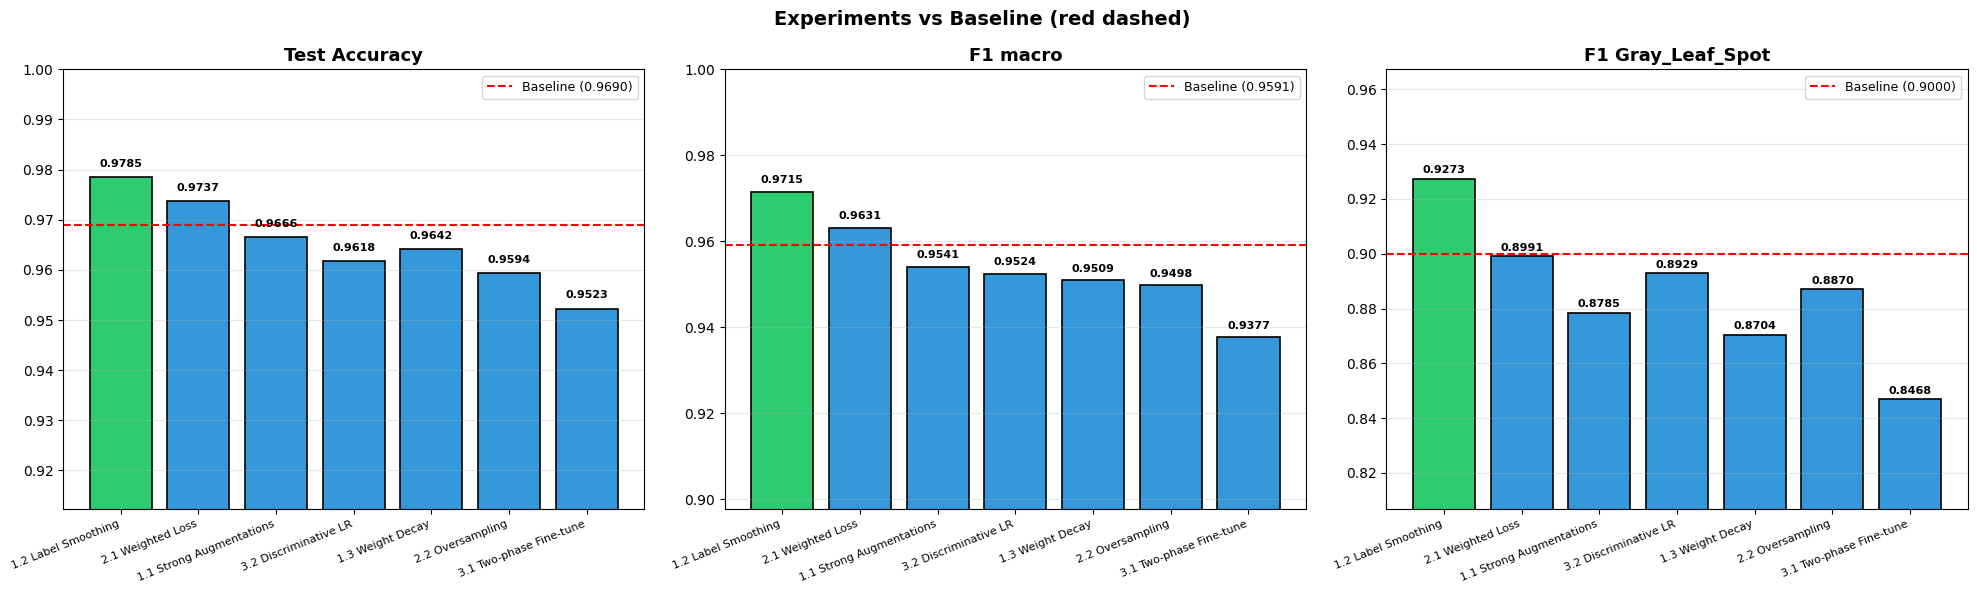

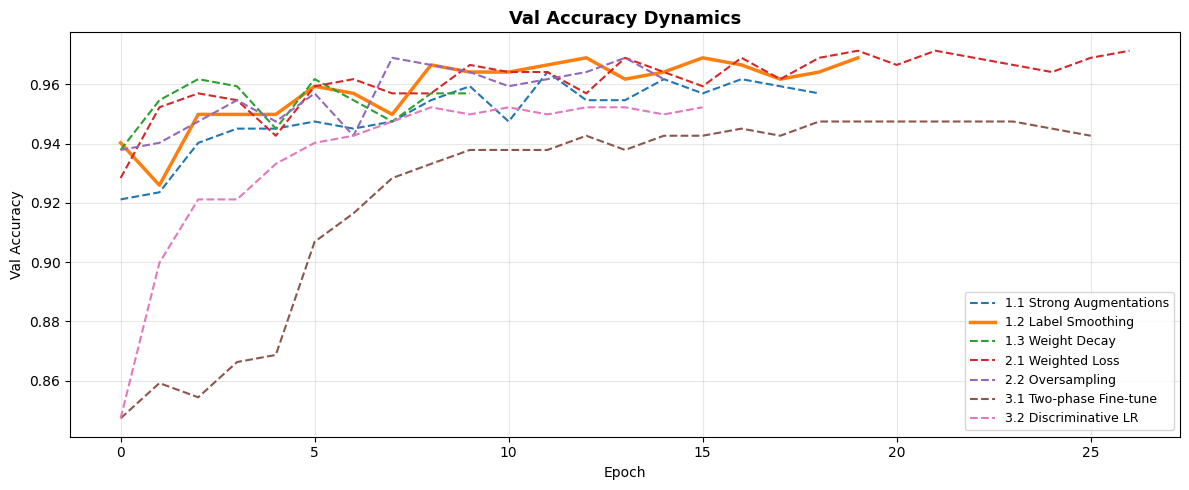


Best experiment: 1.2 Label Smoothing
F1 macro: 0.9715  (baseline: 0.9591)
F1 GLS:   0.9273  (baseline: 0.9000)


In [ ]:
# ============================================================
# BLOCK 4: Final comparison
# ============================================================

sorted_res = sorted(results.values(), key=lambda r: r['f1_macro'], reverse=True)
best_name  = sorted_res[0]['name']

print(f"\n{'='*75}")
print(f"{'Experiment':<28} {'Test Acc':>9} {'F1 macro':>9} {'F1 GLS':>8}  vs baseline")
print('-'*75)
for r in sorted_res:
    delta = r['f1_macro'] - BASELINE['f1_macro']
    sign  = '+' if delta >= 0 else ''
    tag   = ' [BEST]' if r['name'] == best_name else ''
    print(f"{r['name']:<28} {r['test_acc']:>9.4f} {r['f1_macro']:>9.4f}"
          f" {r['f1_gls']:>8.4f}  {sign}{delta:.4f}{tag}")
print(f"{'Baseline ResNet18':<28} {BASELINE['test_acc']:>9.4f}"
      f" {BASELINE['f1_macro']:>9.4f} {BASELINE['f1_gls']:>8.4f}  (ref)")
print('='*75)

# ── Chart 1: metric bars ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
names   = [r['name']     for r in sorted_res]
colors  = ['#2ecc71' if n == best_name else '#3498db' for n in names]
metrics = [
    ([r['test_acc']  for r in sorted_res], 'Test Accuracy',       BASELINE['test_acc']),
    ([r['f1_macro']  for r in sorted_res], 'F1 macro',            BASELINE['f1_macro']),
    ([r['f1_gls']    for r in sorted_res], 'F1 Gray_Leaf_Spot',   BASELINE['f1_gls']),
]
for ax, (vals, title, bv) in zip(axes, metrics):
    bars = ax.bar(range(len(names)), vals, color=colors, edgecolor='black', linewidth=1.2)
    ax.axhline(bv, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({bv:.4f})')
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=22, ha='right', fontsize=8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    all_v = vals + [bv]
    ax.set_ylim(max(0, min(all_v) - 0.04), min(1.0, max(all_v) + 0.04))
    ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Experiments vs Baseline (red dashed)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/figures/experiments_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Chart 2: val_acc dynamics ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for r in results.values():
    ls = '-' if r['name'] == best_name else '--'
    lw = 2.5 if r['name'] == best_name else 1.5
    ax.plot(r['history']['val_acc'], label=r['name'], linestyle=ls, linewidth=lw)
ax.axhline(BASELINE['test_acc'], color='red', linestyle=':', linewidth=1.5,
           label=f"Baseline ({BASELINE['test_acc']:.4f})")
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Accuracy')
ax.set_title('Val Accuracy Dynamics', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/figures/val_acc_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Chart 3: confusion matrix of best experiment ─────────────────────────────
best_r = results[best_name]
cm = confusion_matrix(best_r['labels'], best_r['preds'])
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title(f'Confusion Matrix: {best_name}', fontsize=13, fontweight='bold')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/figures/best_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save summary ─────────────────────────────────────────────────────────────
summary = {
    name: {'test_acc': r['test_acc'], 'f1_macro': r['f1_macro'], 'f1_gls': r['f1_gls']}
    for name, r in results.items()
}
summary['baseline']        = BASELINE
summary['best_experiment'] = best_name
with open(f'{ARTIFACTS_DIR}/experiments_results.json', 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f'\nЛучший эксперимент: {best_name}')
print(f'F1 macro: {best_r["f1_macro"]:.4f}  (baseline: {BASELINE["f1_macro"]:.4f})')
print(f'F1 GLS:   {best_r["f1_gls"]:.4f}  (baseline: {BASELINE["f1_gls"]:.4f})')

# ── Сохраняем лучшую модель как best_model.pt ────────────────────────────────
# src/service.py ожидает artifacts/best_model.pt с чистым state_dict
best_exp_path = f"{ARTIFACTS_DIR}/models/{best_name.replace(' ','_').lower()}.pt"
best_ckpt     = torch.load(best_exp_path, map_location=device)

best_model = make_resnet(NUM_CLASSES)
best_model.load_state_dict(best_ckpt['state_dict'])
best_model.eval()

torch.save(best_model.state_dict(), f"{ARTIFACTS_DIR}/best_model.pt")

# Обновляем config.json в формате, который читает сервис
config_out = {
    'model_name':      'resnet18',
    'num_classes':     NUM_CLASSES,
    'class_names':     CLASSES,
    'class_to_idx':    CLASS_TO_IDX,
    'best_experiment': best_name,
    'test_acc':        float(best_r['test_acc']),
    'f1_macro':        float(best_r['f1_macro']),
    'f1_gls':          float(best_r['f1_gls']),
}
with open(f"{ARTIFACTS_DIR}/config.json", 'w', encoding='utf-8') as f:
    json.dump(config_out, f, indent=2, ensure_ascii=False)
